<a href="https://colab.research.google.com/github/DavidAgudeloM/EA4-PROBLEMA_BANCARIO/blob/main/EA4_SOLUCION_PROBLEMA_PARQUEADERO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Parámetros del problema

Los datos del enunciado se ingresan en minutos. Para los usuarios lentos y muy lentos se reparte el 55% restante en partes iguales: 27.5% y 27.5%.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

np.random.seed(42)

# -----------------------------
# Parámetros del enunciado
# -----------------------------
tipos_usuario = {
    "Rapido":     {"servicio_media": 1, "llegada_media": 3, "prob": 0.25},
    "Normal":     {"servicio_media": 3, "llegada_media": 3, "prob": 0.20},
    "Lento":      {"servicio_media": 4, "llegada_media": 5, "prob": 0.275},
    "Muy lento":  {"servicio_media": 6, "llegada_media": 7, "prob": 0.275},
}

NUM_CAJEROS_ACTUAL = 3
TIEMPO_SIMULACION = 8_000     # minutos por réplica
NUM_REPLICAS = 20             # réplicas para estadísticas

# Tasa global de llegada:
# Se calcula con el promedio ponderado de los tiempos entre llegadas.
media_llegada_global = sum(p["prob"] * p["llegada_media"] for p in tipos_usuario.values())
lambda_global = 1 / media_llegada_global

# Media de servicio ponderada por tipo de usuario
media_servicio_global = sum(p["prob"] * p["servicio_media"] for p in tipos_usuario.values())
mu_global = 1 / media_servicio_global

tabla_parametros = pd.DataFrame([
    {
        "Tipo de usuario": tipo,
        "Probabilidad": p["prob"],
        "Media llegada (min)": p["llegada_media"],
        "Media servicio (min)": p["servicio_media"],
        "lambda individual aprox.": 1 / p["llegada_media"],
        "mu individual": 1 / p["servicio_media"],
    }
    for tipo, p in tipos_usuario.items()
])

print("Media global entre llegadas:", round(media_llegada_global, 3), "min")
print("Lambda global:", round(lambda_global, 4), "clientes/min")
print("Media global de servicio:", round(media_servicio_global, 3), "min")
print("Mu global:", round(mu_global, 4), "clientes/min")
display(tabla_parametros)

Media global entre llegadas: 4.65 min
Lambda global: 0.2151 clientes/min
Media global de servicio: 3.6 min
Mu global: 0.2778 clientes/min


,Tipo de usuario,Probabilidad,Media llegada (min),Media servicio (min),lambda individual aprox.,mu individual
0,Rapido,0.250,3,1,0.333333,1.000000
1,Normal,0.200,3,3,0.333333,0.333333
2,Lento,0.275,5,4,0.200000,0.250000
3,Muy lento,0.275,7,6,0.142857,0.166667


## 2. Simulador M/M/1 para cajeros independientes

Cada cajero se modela como una cola **M/M/1**. La llegada global se divide entre el número de cajeros disponibles para no duplicar artificialmente la demanda.

In [ ]:
def seleccionar_tipo_usuario(rng):
    tipos = list(tipos_usuario.keys())
    probs = [tipos_usuario[t]["prob"] for t in tipos]
    return rng.choice(tipos, p=probs)


def simular_cajero_mm1(lambda_por_cajero, tiempo_simulacion, seed=None):
    """Simula un cajero M/M/1 con mezcla de tipos de usuario."""
    rng = np.random.default_rng(seed)

    tiempo_actual = 0.0
    servidor_libre_en = 0.0
    registros = []
    cliente_id = 0

    while tiempo_actual < tiempo_simulacion:
        # Llegada Poisson: tiempo entre llegadas exponencial
        tiempo_actual += rng.exponential(1 / lambda_por_cajero)
        if tiempo_actual > tiempo_simulacion:
            break

        tipo = seleccionar_tipo_usuario(rng)
        media_servicio = tipos_usuario[tipo]["servicio_media"]
        tiempo_servicio = rng.exponential(media_servicio)

        inicio_servicio = max(tiempo_actual, servidor_libre_en)
        tiempo_espera = inicio_servicio - tiempo_actual
        salida = inicio_servicio + tiempo_servicio
        tiempo_sistema = salida - tiempo_actual
        servidor_libre_en = salida

        registros.append({
            "cliente": cliente_id,
            "tipo_usuario": tipo,
            "llegada": tiempo_actual,
            "inicio_servicio": inicio_servicio,
            "salida": salida,
            "tiempo_servicio": tiempo_servicio,
            "tiempo_espera": tiempo_espera,
            "tiempo_sistema": tiempo_sistema
        })
        cliente_id += 1

    return pd.DataFrame(registros)


def simular_sistema(num_cajeros, tiempo_simulacion, num_replicas):
    """Simula el sistema completo con num_cajeros cajeros independientes."""
    lambda_por_cajero = lambda_global / num_cajeros
    resultados = []

    for replica in range(1, num_replicas + 1):
        for cajero in range(1, num_cajeros + 1):
            df = simular_cajero_mm1(
                lambda_por_cajero=lambda_por_cajero,
                tiempo_simulacion=tiempo_simulacion,
                seed=1000 * replica + cajero
            )
            df["replica"] = replica
            df["cajero"] = cajero
            resultados.append(df)

    return pd.concat(resultados, ignore_index=True)


datos = simular_sistema(NUM_CAJEROS_ACTUAL, TIEMPO_SIMULACION, NUM_REPLICAS)
datos.head()

,cliente,tipo_usuario,llegada,inicio_servicio,salida,tiempo_servicio,tiempo_espera,tiempo_sistema,replica,cajero
0,0,Rapido,8.756674,8.756674,8.922898,0.166223,0.0,0.166223,1,1
1,1,Rapido,21.788037,21.788037,21.910131,0.122093,0.0,0.122093,1,1
2,2,Rapido,51.253122,51.253122,51.368058,0.114936,0.0,0.114936,1,1
3,3,Rapido,58.856464,58.856464,60.875087,2.018623,0.0,2.018623,1,1
4,4,Normal,66.916743,66.916743,71.252431,4.335688,0.0,4.335688,1,1


## 3. Control de réplicas y datos simulados

Antes de calcular conclusiones, se deja visible con cuántas réplicas corre el modelo y cómo se comporta cada una. Esto permite revisar si una réplica salió más congestionada que otra y entender que el resultado final no depende de una sola corrida.

In [ ]:
# ---------------------------------------------------------
# Control de réplicas y revisión de datos generados
# ---------------------------------------------------------
print("CONFIGURACIÓN DE LA SIMULACIÓN")
print(f"Número de cajeros simulados: {NUM_CAJEROS_ACTUAL}")
print(f"Número de réplicas ejecutadas: {NUM_REPLICAS}")
print(f"Tiempo de simulación por réplica: {TIEMPO_SIMULACION:,} minutos")
print(f"Tasa de llegada global: {lambda_global:.4f} clientes/minuto")
print(f"Tasa de llegada por cajero: {lambda_global / NUM_CAJEROS_ACTUAL:.4f} clientes/minuto")

print("\nComentario personal:")
print("Cada réplica es como repetir el mismo experimento desde cero. Por eso no se analiza una sola corrida, sino varias, para observar si el comportamiento se mantiene estable.")

# Resumen por réplica y cajero, todavía sin eliminar transitorio
resumen_replica_cajero = (
    datos.groupby(["replica", "cajero"])
    .agg(
        clientes=("cliente", "count"),
        W_promedio=("tiempo_sistema", "mean"),
        Wq_promedio=("tiempo_espera", "mean"),
        servicio_promedio=("tiempo_servicio", "mean"),
        espera_maxima=("tiempo_espera", "max")
    )
    .reset_index()
)

print("\nTabla 1. Comportamiento por réplica y por cajero")
print("Esta tabla ayuda a ver si en alguna réplica un cajero tuvo más espera o más clientes que los demás.")
display(resumen_replica_cajero.round(3))

# Resumen general por réplica, promediando los cajeros
resumen_replica = (
    datos.groupby("replica")
    .agg(
        clientes_totales=("cliente", "count"),
        W_promedio=("tiempo_sistema", "mean"),
        Wq_promedio=("tiempo_espera", "mean"),
        servicio_promedio=("tiempo_servicio", "mean")
    )
    .reset_index()
)

print("\nTabla 2. Resumen general por réplica")
print("Aquí cada fila representa una réplica completa. Si los valores son parecidos, el sistema está mostrando un comportamiento consistente.")
display(resumen_replica.round(3))

# Muestra de datos de clientes de cada réplica para revisar el comportamiento interno
muestra_por_replica = (
    datos.sort_values(["replica", "cajero", "cliente"])
    .groupby("replica")
    .head(5)
    [["replica", "cajero", "cliente", "tipo_usuario", "llegada", "tiempo_servicio", "tiempo_espera", "tiempo_sistema"]]
)

print("\nTabla 3. Primeros datos simulados de cada réplica")
print("Esta tabla no es la conclusión final; sirve para revisar datos reales generados por la simulación en cada réplica.")
display(muestra_por_replica.round(3))

CONFIGURACIÓN DE LA SIMULACIÓN
Número de cajeros simulados: 3
Número de réplicas ejecutadas: 20
Tiempo de simulación por réplica: 8,000 minutos
Tasa de llegada global: 0.2151 clientes/minuto
Tasa de llegada por cajero: 0.0717 clientes/minuto

Comentario personal:
Cada réplica es como repetir el mismo experimento desde cero. Por eso no se analiza una sola corrida, sino varias, para observar si el comportamiento se mantiene estable.

Tabla 1. Comportamiento por réplica y por cajero
Esta tabla ayuda a ver si en alguna réplica un cajero tuvo más espera o más clientes que los demás.


,replica,cajero,clientes,W_promedio,Wq_promedio,servicio_promedio,espera_maxima
0,1,1,546,6.012,2.210,3.803,46.807
1,1,2,574,5.358,1.826,3.532,57.888
2,1,3,580,5.039,1.542,3.496,31.351
3,2,1,540,4.959,1.175,3.784,35.437
4,2,2,589,5.887,2.011,3.875,43.556
5,2,3,572,5.097,1.452,3.644,42.482
6,3,1,512,5.487,1.666,3.822,29.114
7,3,2,580,5.142,1.737,3.405,35.698
8,3,3,619,5.911,2.129,3.782,42.543
9,4,1,577,4.836,1.331,3.505,38.084



Tabla 2. Resumen general por réplica
Aquí cada fila representa una réplica completa. Si los valores son parecidos, el sistema está mostrando un comportamiento consistente.


,replica,clientes_totales,W_promedio,Wq_promedio,servicio_promedio
0,1,1700,5.459,1.852,3.607
1,2,1701,5.326,1.558,3.769
2,3,1711,5.524,1.858,3.666
3,4,1773,4.856,1.294,3.561
4,5,1784,5.035,1.541,3.494
5,6,1730,5.327,1.583,3.744
6,7,1752,5.232,1.533,3.699
7,8,1776,5.856,2.052,3.805
8,9,1779,5.364,1.772,3.591
9,10,1752,4.776,1.216,3.560



Tabla 3. Primeros datos simulados de cada réplica
Esta tabla no es la conclusión final; sirve para revisar datos reales generados por la simulación en cada réplica.


,replica,cajero,cliente,tipo_usuario,llegada,tiempo_servicio,tiempo_espera,tiempo_sistema
0,1,1,0,Rapido,8.757,0.166,0.0,0.166
1,1,1,1,Rapido,21.788,0.122,0.0,0.122
2,1,1,2,Rapido,51.253,0.115,0.0,0.115
3,1,1,3,Rapido,58.856,2.019,0.0,2.019
4,1,1,4,Normal,66.917,4.336,0.0,4.336
...,...,...,...,...,...,...,...,...
33121,20,1,0,Muy lento,4.878,3.899,0.0,3.899
33122,20,1,1,Lento,12.311,2.265,0.0,2.265
33123,20,1,2,Muy lento,35.284,8.482,0.0,8.482
33124,20,1,3,Muy lento,47.938,0.033,0.0,0.033


## 3. Identificación del estado estable

Se usa la técnica del promedio acumulado y promedio móvil. Para eliminar el estado transitorio se toma un punto de corte conservador del **10% inicial** de los clientes de cada réplica y cajero. También se grafica el comportamiento antes y después.

In [ ]:
def aplicar_estado_estable(df, porcentaje_corte=0.10):
    cortes = (
        df.groupby(["replica", "cajero"])["cliente"]
        .max()
        .reset_index()
        .rename(columns={"cliente": "cliente_max"})
    )
    cortes["corte"] = (cortes["cliente_max"] * porcentaje_corte).astype(int)

    df2 = df.merge(cortes[["replica", "cajero", "corte"]], on=["replica", "cajero"], how="left")
    df2["estado"] = np.where(df2["cliente"] <= df2["corte"], "Transitorio", "Estable")
    return df2


datos_estado = aplicar_estado_estable(datos, porcentaje_corte=0.10)
datos_estables = datos_estado[datos_estado["estado"] == "Estable"].copy()

print("Clientes simulados totales:", len(datos_estado))
print("Clientes usados en estado estable:", len(datos_estables))
display(datos_estado[["replica", "cajero", "cliente", "tipo_usuario", "tiempo_espera", "tiempo_sistema", "estado"]].head())

Clientes simulados totales: 34861
Clientes usados en estado estable: 31351


,replica,cajero,cliente,tipo_usuario,tiempo_espera,tiempo_sistema,estado
0,1,1,0,Rapido,0.0,0.166223,Transitorio
1,1,1,1,Rapido,0.0,0.122093,Transitorio
2,1,1,2,Rapido,0.0,0.114936,Transitorio
3,1,1,3,Rapido,0.0,2.018623,Transitorio
4,1,1,4,Normal,0.0,4.335688,Transitorio


In [ ]:
# ---------------------------------------------------------
# Resultados por réplica después de eliminar el transitorio
# ---------------------------------------------------------
resumen_replica_estable = (
    datos_estables.groupby(["replica", "cajero"])
    .agg(
        clientes_estables=("cliente", "count"),
        W_promedio_estable=("tiempo_sistema", "mean"),
        Wq_promedio_estable=("tiempo_espera", "mean"),
        servicio_promedio_estable=("tiempo_servicio", "mean")
    )
    .reset_index()
)

print("Tabla 4. Comportamiento por réplica y cajero, solo en estado estable")
print("Esta es una de las tablas más importantes: ya no incluye los primeros datos de calentamiento del sistema.")
display(resumen_replica_estable.round(3))

resumen_estado_por_replica = (
    datos_estado.groupby(["replica", "estado"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
resumen_estado_por_replica["Total"] = resumen_estado_por_replica.get("Estable", 0) + resumen_estado_por_replica.get("Transitorio", 0)
resumen_estado_por_replica["% estable"] = resumen_estado_por_replica.get("Estable", 0) / resumen_estado_por_replica["Total"]

print("\nTabla 5. Cantidad de datos transitorios y estables por réplica")
print("Esta tabla muestra cuántos datos se conservaron para el análisis final y cuántos se eliminaron como calentamiento inicial.")
display(resumen_estado_por_replica.round(3))

Tabla 4. Comportamiento por réplica y cajero, solo en estado estable
Esta es una de las tablas más importantes: ya no incluye los primeros datos de calentamiento del sistema.


,replica,cajero,clientes_estables,W_promedio_estable,Wq_promedio_estable,servicio_promedio_estable
0,1,1,491,5.773,2.009,3.764
1,1,2,516,5.144,1.633,3.511
2,1,3,522,4.954,1.502,3.452
3,2,1,486,4.752,1.101,3.651
4,2,2,530,6.025,2.117,3.908
5,2,3,514,5.135,1.469,3.667
6,3,1,460,5.474,1.730,3.744
7,3,2,522,4.920,1.631,3.289
8,3,3,557,6.154,2.325,3.829
9,4,1,519,4.910,1.320,3.590



Tabla 5. Cantidad de datos transitorios y estables por réplica
Esta tabla muestra cuántos datos se conservaron para el análisis final y cuántos se eliminaron como calentamiento inicial.


estado,replica,Estable,Transitorio,Total,% estable
0,1,1529,171,1700,0.899
1,2,1530,171,1701,0.899
2,3,1539,172,1711,0.899
3,4,1595,178,1773,0.900
4,5,1605,179,1784,0.900
5,6,1556,174,1730,0.899
6,7,1576,176,1752,0.900
7,8,1597,179,1776,0.899
8,9,1599,180,1779,0.899
9,10,1575,177,1752,0.899


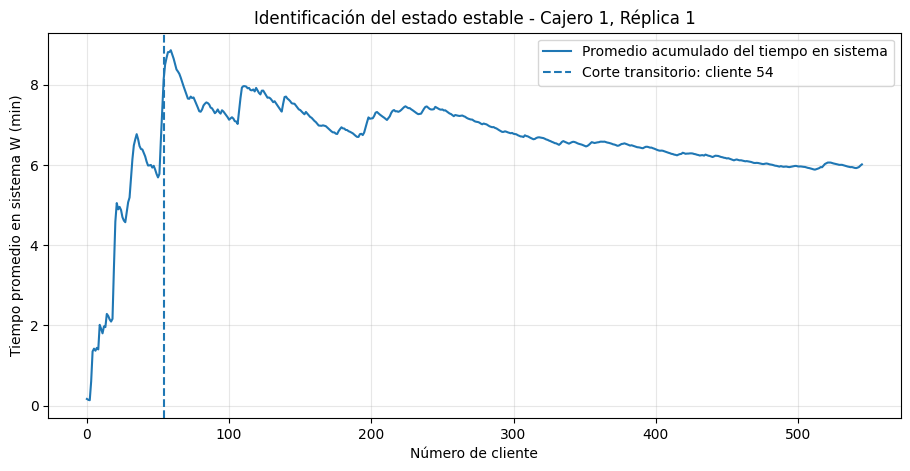

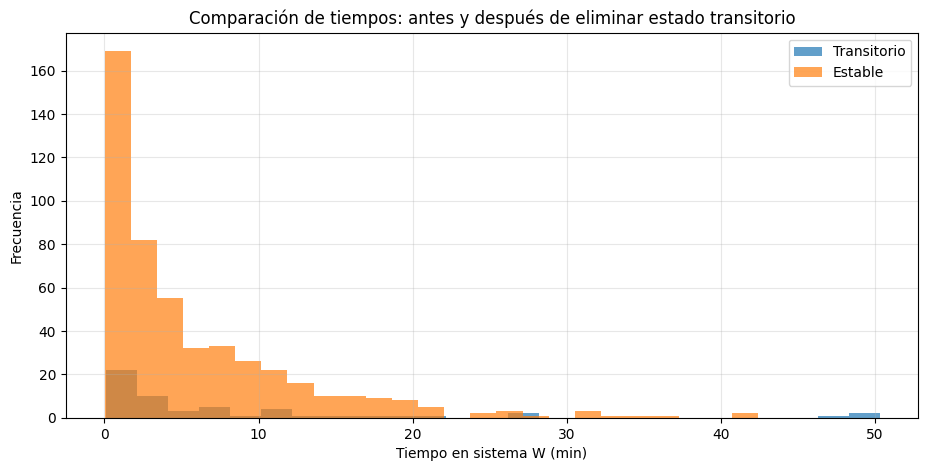

In [ ]:
# Gráfica del promedio acumulado para una réplica y un cajero de referencia
ejemplo = datos_estado[(datos_estado["replica"] == 1) & (datos_estado["cajero"] == 1)].copy()
ejemplo["promedio_acumulado_W"] = ejemplo["tiempo_sistema"].expanding().mean()
corte_ejemplo = int(ejemplo["corte"].iloc[0])

plt.figure(figsize=(11, 5))
plt.plot(ejemplo["cliente"], ejemplo["promedio_acumulado_W"], label="Promedio acumulado del tiempo en sistema")
plt.axvline(corte_ejemplo, linestyle="--", label=f"Corte transitorio: cliente {corte_ejemplo}")
plt.title("Identificación del estado estable - Cajero 1, Réplica 1")
plt.xlabel("Número de cliente")
plt.ylabel("Tiempo promedio en sistema W (min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Antes y después del corte
plt.figure(figsize=(11, 5))
plt.hist(ejemplo[ejemplo["estado"] == "Transitorio"]["tiempo_sistema"], bins=25, alpha=0.7, label="Transitorio")
plt.hist(ejemplo[ejemplo["estado"] == "Estable"]["tiempo_sistema"], bins=25, alpha=0.7, label="Estable")
plt.title("Comparación de tiempos: antes y después de eliminar estado transitorio")
plt.xlabel("Tiempo en sistema W (min)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Punto A: estadísticas por cajero

Se calculan media, desviación estándar, mínimo, máximo e intervalo de confianza del 95% del tiempo total de atención en sistema (**W**).

In [ ]:
def intervalo_confianza_95(serie):
    serie = pd.Series(serie).dropna()
    n = len(serie)
    media = serie.mean()
    if n <= 1:
        return media, media
    error = stats.t.ppf(0.975, n - 1) * serie.std(ddof=1) / np.sqrt(n)
    return media - error, media + error


resumen_cajero = (
    datos_estables.groupby("cajero")
    .agg(
        clientes=("cliente", "count"),
        media_W=("tiempo_sistema", "mean"),
        media_Wq=("tiempo_espera", "mean"),
        media_servicio=("tiempo_servicio", "mean"),
        desv_W=("tiempo_sistema", "std"),
        minimo_W=("tiempo_sistema", "min"),
        maximo_W=("tiempo_sistema", "max")
    )
    .reset_index()
)

ics = datos_estables.groupby("cajero")["tiempo_sistema"].apply(intervalo_confianza_95).reset_index()
ics[["IC95_inf_W", "IC95_sup_W"]] = pd.DataFrame(ics["tiempo_sistema"].tolist(), index=ics.index)
resumen_cajero = resumen_cajero.merge(ics[["cajero", "IC95_inf_W", "IC95_sup_W"]], on="cajero")

mejor_cajero = resumen_cajero.loc[resumen_cajero["media_W"].idxmin()]
peor_cajero = resumen_cajero.loc[resumen_cajero["media_W"].idxmax()]

display(resumen_cajero.round(3))
print(f"Cajero con menor tiempo promedio: Cajero {int(mejor_cajero['cajero'])} con W = {mejor_cajero['media_W']:.3f} min")
print(f"Cajero con mayor tiempo promedio: Cajero {int(peor_cajero['cajero'])} con W = {peor_cajero['media_W']:.3f} min")

,cajero,clientes,media_W,media_Wq,media_servicio,desv_W,minimo_W,maximo_W,IC95_inf_W,IC95_sup_W
0,1,10404,5.171,1.528,3.643,5.953,0.0,56.262,5.056,5.285
1,2,10483,5.160,1.614,3.547,6.141,0.0,59.537,5.043,5.278
2,3,10464,5.173,1.572,3.601,6.075,0.0,61.045,5.056,5.289


Cajero con menor tiempo promedio: Cajero 2 con W = 5.160 min
Cajero con mayor tiempo promedio: Cajero 3 con W = 5.173 min


## 5. Punto B: promedio de usuarios por tipo

Se calcula la participación observada por tipo de usuario y el tiempo promedio que cada tipo permanece en el sistema.

,tipo_usuario,clientes,media_W,media_Wq,media_servicio,porcentaje_observado,porcentaje_esperado,diferencia
0,Lento,8633,5.6229,1.6114,4.0115,0.2754,0.275,0.0004
1,Muy lento,8631,7.5257,1.5523,5.9733,0.2753,0.275,0.0003
2,Normal,6205,4.5026,1.4966,3.0059,0.1979,0.200,-0.0021
3,Rapido,7882,2.6119,1.6069,1.0049,0.2514,0.250,0.0014


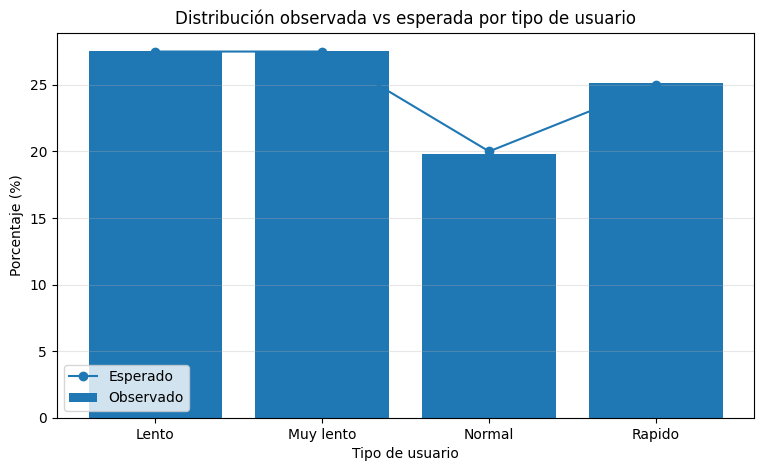

In [ ]:
resumen_tipo = (
    datos_estables.groupby("tipo_usuario")
    .agg(
        clientes=("cliente", "count"),
        media_W=("tiempo_sistema", "mean"),
        media_Wq=("tiempo_espera", "mean"),
        media_servicio=("tiempo_servicio", "mean")
    )
    .reset_index()
)

total_estable = resumen_tipo["clientes"].sum()
resumen_tipo["porcentaje_observado"] = resumen_tipo["clientes"] / total_estable
resumen_tipo["porcentaje_esperado"] = resumen_tipo["tipo_usuario"].map({t: p["prob"] for t, p in tipos_usuario.items()})
resumen_tipo["diferencia"] = resumen_tipo["porcentaje_observado"] - resumen_tipo["porcentaje_esperado"]

display(resumen_tipo.round(4))

plt.figure(figsize=(9, 5))
plt.bar(resumen_tipo["tipo_usuario"], resumen_tipo["porcentaje_observado"] * 100, label="Observado")
plt.plot(resumen_tipo["tipo_usuario"], resumen_tipo["porcentaje_esperado"] * 100, marker="o", label="Esperado")
plt.title("Distribución observada vs esperada por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Porcentaje (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Punto C: decisión y estrategia de mejora

Criterios usados para tomar la decisión:

-  Tiempo en Cola **Wq** es aceptable si el tiempo promedio en cola es menor o igual a 3 minutos.
- Tiempo del sistema **W** es aceptable si el tiempo promedio total en sistema es menor o igual a 6 minutos.
- Utilización **ρ** es aceptable si la utilización promedio es menor a 85%.
- Si 3 cajeros cumplen estos criterios, se recomienda mantenerlos. Si no cumplen, se compara con 4 cajeros.

,cajeros,lambda_por_cajero,rho_estimado,clientes,W_promedio,Wq_promedio,servicio_promedio
0,2,0.1075,0.3871,31079,6.3692,2.7835,3.5857
1,3,0.0717,0.2581,31351,5.1680,1.5713,3.5967
2,4,0.0538,0.1935,31375,4.6822,1.0895,3.5927
3,5,0.0430,0.1548,31298,4.4614,0.8453,3.6161


Decisión:
Con 3 cajeros el sistema es suficiente según los criterios definidos.
Estrategia: mantener los 3 cajeros, monitorear horas pico y habilitar señalización para usuarios rápidos.


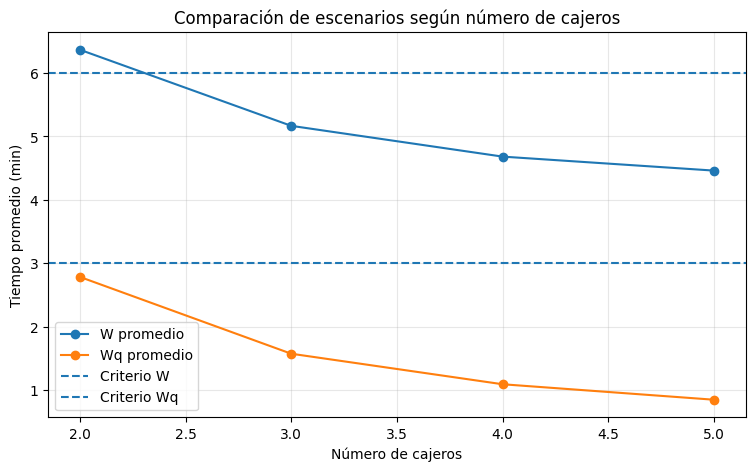

In [ ]:
def evaluar_escenario(num_cajeros, tiempo_simulacion=TIEMPO_SIMULACION, num_replicas=NUM_REPLICAS):
    df = simular_sistema(num_cajeros, tiempo_simulacion, num_replicas)
    df = aplicar_estado_estable(df, porcentaje_corte=0.10)
    estable = df[df["estado"] == "Estable"].copy()

    lambda_por_cajero = lambda_global / num_cajeros
    rho = lambda_por_cajero / mu_global

    return {
        "cajeros": num_cajeros,
        "lambda_por_cajero": lambda_por_cajero,
        "rho_estimado": rho,
        "clientes": len(estable),
        "W_promedio": estable["tiempo_sistema"].mean(),
        "Wq_promedio": estable["tiempo_espera"].mean(),
        "servicio_promedio": estable["tiempo_servicio"].mean(),
    }


escenarios = pd.DataFrame([evaluar_escenario(c) for c in [2, 3, 4, 5]])
display(escenarios.round(4))

criterio_Wq = 3
criterio_W = 6
criterio_rho = 0.85

actual = escenarios[escenarios["cajeros"] == NUM_CAJEROS_ACTUAL].iloc[0]
cumple = (
    actual["Wq_promedio"] <= criterio_Wq
    and actual["W_promedio"] <= criterio_W
    and actual["rho_estimado"] < criterio_rho
)

print("Decisión:")
if cumple:
    print("Con 3 cajeros el sistema es suficiente según los criterios definidos.")
    print("Estrategia: mantener los 3 cajeros, monitorear horas pico y habilitar señalización para usuarios rápidos.")
else:
    print("Con 3 cajeros el sistema no cumple los criterios definidos.")
    print("Estrategia: instalar un cajero adicional o implementar un cajero exprés para usuarios rápidos.")

plt.figure(figsize=(9, 5))
plt.plot(escenarios["cajeros"], escenarios["W_promedio"], marker="o", label="W promedio")
plt.plot(escenarios["cajeros"], escenarios["Wq_promedio"], marker="o", label="Wq promedio")
plt.axhline(criterio_W, linestyle="--", label="Criterio W")
plt.axhline(criterio_Wq, linestyle="--", label="Criterio Wq")
plt.title("Comparación de escenarios según número de cajeros")
plt.xlabel("Número de cajeros")
plt.ylabel("Tiempo promedio (min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Punto D: verificación, calibración y validación


In [ ]:
lambda_por_cajero_actual = lambda_global / NUM_CAJEROS_ACTUAL
rho_teorico = lambda_por_cajero_actual / mu_global
rho_simulado = datos_estables.groupby("cajero")["tiempo_servicio"].mean().mean() * lambda_por_cajero_actual

validacion = pd.DataFrame({
    "Indicador": ["Lambda global", "Lambda por cajero", "Mu global", "Rho teórico", "Rho simulado aprox."],
    "Valor": [lambda_global, lambda_por_cajero_actual, mu_global, rho_teorico, rho_simulado]
})

display(validacion.round(4))

print("Interpretación:")
print(f"La utilización teórica por cajero es aproximadamente {rho_teorico:.2%}.")
print("Como está por debajo del 85%, el sistema no se encuentra saturado con 3 cajeros.")

,Indicador,Valor
0,Lambda global,0.2151
1,Lambda por cajero,0.0717
2,Mu global,0.2778
3,Rho teórico,0.2581
4,Rho simulado aprox.,0.2578


Interpretación:
La utilización teórica por cajero es aproximadamente 25.81%.
Como está por debajo del 85%, el sistema no se encuentra saturado con 3 cajeros.


## 8. Punto E: antes y después de eliminar el estado transitorio

La siguiente tabla compara los resultados incluyendo todos los datos contra los resultados después de retirar el 10% inicial.

,Escenario,Clientes,W_promedio,Wq_promedio,Servicio_promedio
0,Antes: con transitorio,34861,5.1691,1.5676,3.6016
1,Después: solo estable,31351,5.1680,1.5713,3.5967


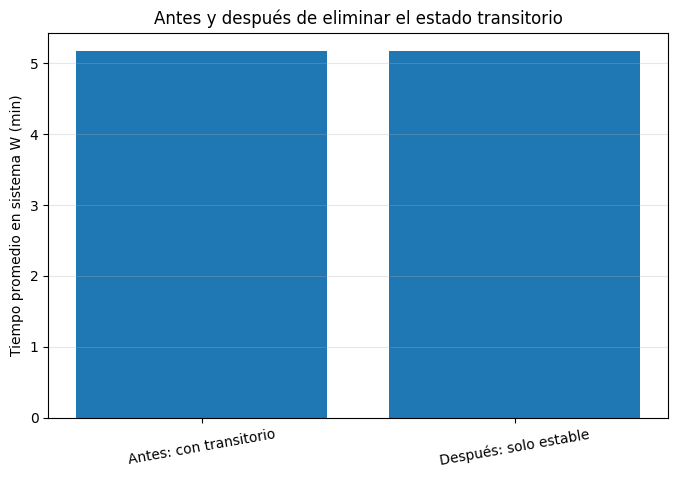

In [ ]:
comparacion_estado = pd.DataFrame({
    "Escenario": ["Antes: con transitorio", "Después: solo estable"],
    "Clientes": [len(datos_estado), len(datos_estables)],
    "W_promedio": [datos_estado["tiempo_sistema"].mean(), datos_estables["tiempo_sistema"].mean()],
    "Wq_promedio": [datos_estado["tiempo_espera"].mean(), datos_estables["tiempo_espera"].mean()],
    "Servicio_promedio": [datos_estado["tiempo_servicio"].mean(), datos_estables["tiempo_servicio"].mean()]
})

display(comparacion_estado.round(4))

plt.figure(figsize=(8, 5))
plt.bar(comparacion_estado["Escenario"], comparacion_estado["W_promedio"])
plt.title("Antes y después de eliminar el estado transitorio")
plt.ylabel("Tiempo promedio en sistema W (min)")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Análisis final de la ejecución


In [ ]:
# ---------------------------------------------------------
# Análisis final automático con base en los resultados ejecutados
# ---------------------------------------------------------
mejor_cajero = resumen_cajero.loc[resumen_cajero["media_W"].idxmin()]
peor_cajero = resumen_cajero.loc[resumen_cajero["media_W"].idxmax()]
W_global = datos_estables["tiempo_sistema"].mean()
Wq_global = datos_estables["tiempo_espera"].mean()
serv_global = datos_estables["tiempo_servicio"].mean()
rho_actual = (lambda_global / NUM_CAJEROS_ACTUAL) / mu_global

print("ANÁLISIS PERSONAL FINAL")
print("=" * 80)
print(f"La simulación se ejecutó con {NUM_REPLICAS} réplicas, {NUM_CAJEROS_ACTUAL} cajeros y {TIEMPO_SIMULACION:,} minutos por réplica.")
print("Esto significa que el sistema se repitió varias veces para no tomar decisiones con una sola corrida.")
print()
print("1. Sobre las tablas por réplica:")
print("   Las tablas por réplica muestran que cada corrida genera resultados diferentes, porque las llegadas y los tiempos de servicio son aleatorios.")
print("   Sin embargo, al promediar varias réplicas se obtiene una medida más confiable del comportamiento del parqueadero.")
print()
print("2. Sobre el estado estable:")
print("   Se eliminó el 10% inicial de clientes de cada réplica y cajero porque al comienzo el sistema está vacío.")
print("   Si se dejan esos datos iniciales, los tiempos promedio pueden verse artificialmente bajos y la conclusión puede ser engañosa.")
print()
print("3. Sobre los cajeros:")
print(f"   El cajero con menor tiempo promedio total en el sistema fue el Cajero {int(mejor_cajero['cajero'])}, con W = {mejor_cajero['media_W']:.2f} minutos.")
print(f"   El cajero con mayor tiempo promedio total en el sistema fue el Cajero {int(peor_cajero['cajero'])}, con W = {peor_cajero['media_W']:.2f} minutos.")
print("   Como todos los cajeros tienen la misma lógica de atención, esas diferencias se explican por la aleatoriedad propia de cada réplica.")
print()
print("4. Sobre los tiempos generales del sistema:")
print(f"   El tiempo promedio total en el sistema fue W = {W_global:.2f} minutos.")
print(f"   El tiempo promedio en cola fue Wq = {Wq_global:.2f} minutos.")
print(f"   El tiempo promedio de servicio fue {serv_global:.2f} minutos.")
print(f"   La utilización aproximada del sistema con 3 cajeros fue rho = {rho_actual:.3f}.")
print()
print("5. Interpretación para la decisión:")
if rho_actual < 0.85 and Wq_global <= 3 and W_global <= 6:
    print("   Con los criterios definidos, los 3 cajeros son suficientes porque la cola, el tiempo total y la utilización están dentro de rangos aceptables.")
    print("   La recomendación es mantener 3 cajeros, pero monitorear horarios pico y usuarios lentos o muy lentos.")
else:
    print("   Con los criterios definidos, 3 cajeros no son suficientes porque al menos un indicador supera el límite aceptable.")
    print("   La recomendación es instalar un cajero adicional o aplicar una estrategia para atender más rápido a usuarios lentos y muy lentos.")
print()
print("6. Qué aprendí de la actividad:")
print("   La actividad no busca solo correr código, sino tomar una decisión con datos simulados.")
print("   Las réplicas permiten comparar varios escenarios posibles, el estado estable evita conclusiones sesgadas y las tablas ayudan a justificar si se necesitan más cajeros.")

ANÁLISIS PERSONAL FINAL
La simulación se ejecutó con 20 réplicas, 3 cajeros y 8,000 minutos por réplica.
Esto significa que el sistema se repitió varias veces para no tomar decisiones con una sola corrida.

1. Sobre las tablas por réplica:
   Las tablas por réplica muestran que cada corrida genera resultados diferentes, porque las llegadas y los tiempos de servicio son aleatorios.
   Sin embargo, al promediar varias réplicas se obtiene una medida más confiable del comportamiento del parqueadero.

2. Sobre el estado estable:
   Se eliminó el 10% inicial de clientes de cada réplica y cajero porque al comienzo el sistema está vacío.
   Si se dejan esos datos iniciales, los tiempos promedio pueden verse artificialmente bajos y la conclusión puede ser engañosa.

3. Sobre los cajeros:
   El cajero con menor tiempo promedio total en el sistema fue el Cajero 2, con W = 5.16 minutos.
   El cajero con mayor tiempo promedio total en el sistema fue el Cajero 3, con W = 5.17 minutos.
   Como todos 